# VFA-1 — Environment Visualisation

Test notebook for `FogGridWorld`.  Covers:
1. Initial state — agent view vs. full map
2. Random episode walkthrough
3. Energy → radius shrinkage
4. Step-by-step animation

In [1]:
import sys
from pathlib import Path

# Auto-locate vfa1_navigating_fog/ regardless of where Jupyter was launched.
root = Path.cwd()
while not (root / 'src' / 'environment').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
import numpy as np

from src.environment.grid_world import FogGridWorld
from src.environment.cell_types import CellType, Action

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. Initial State

Left: **agent view** (`fog=True`) — what the agent actually observes.  
Right: **full map** (`fog=False`) — ground truth for debugging.

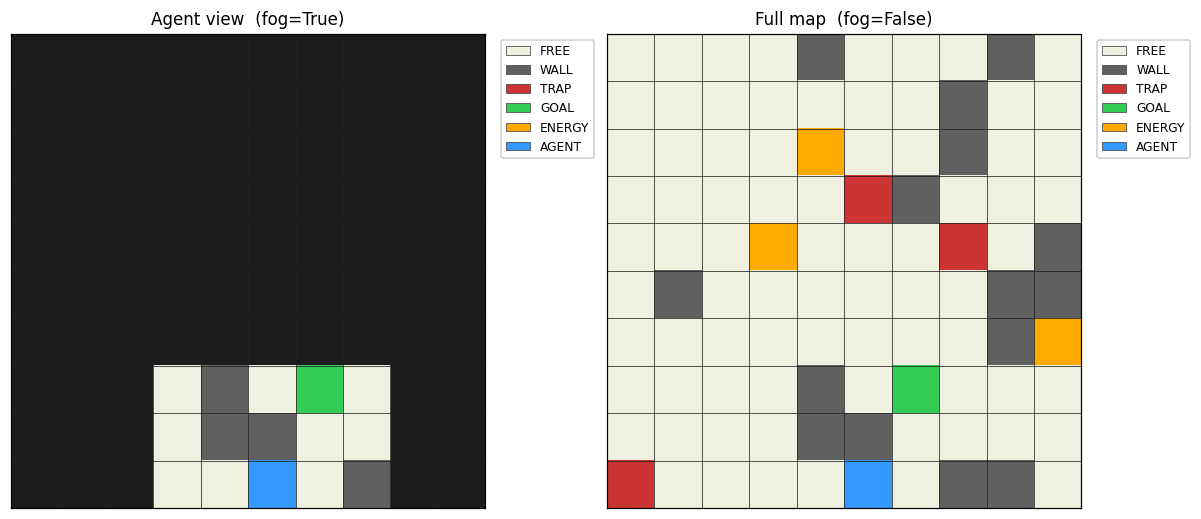

In [ ]:
env = FogGridWorld(grid_size=10)
env.reset(seed=0)

fig, (ax_fog, ax_full) = plt.subplots(1, 2, figsize=(11, 5))
env.render_frame(ax_fog,  fog=True)
env.render_frame(ax_full, fog=False)
ax_fog.set_title('Agent view  (fog=True)',  fontsize=11)
ax_full.set_title('Full map  (fog=False)', fontsize=11)
plt.tight_layout()
plt.show()

## 2. Episode Walkthrough

Run a random episode and capture a frame every `interval` steps.

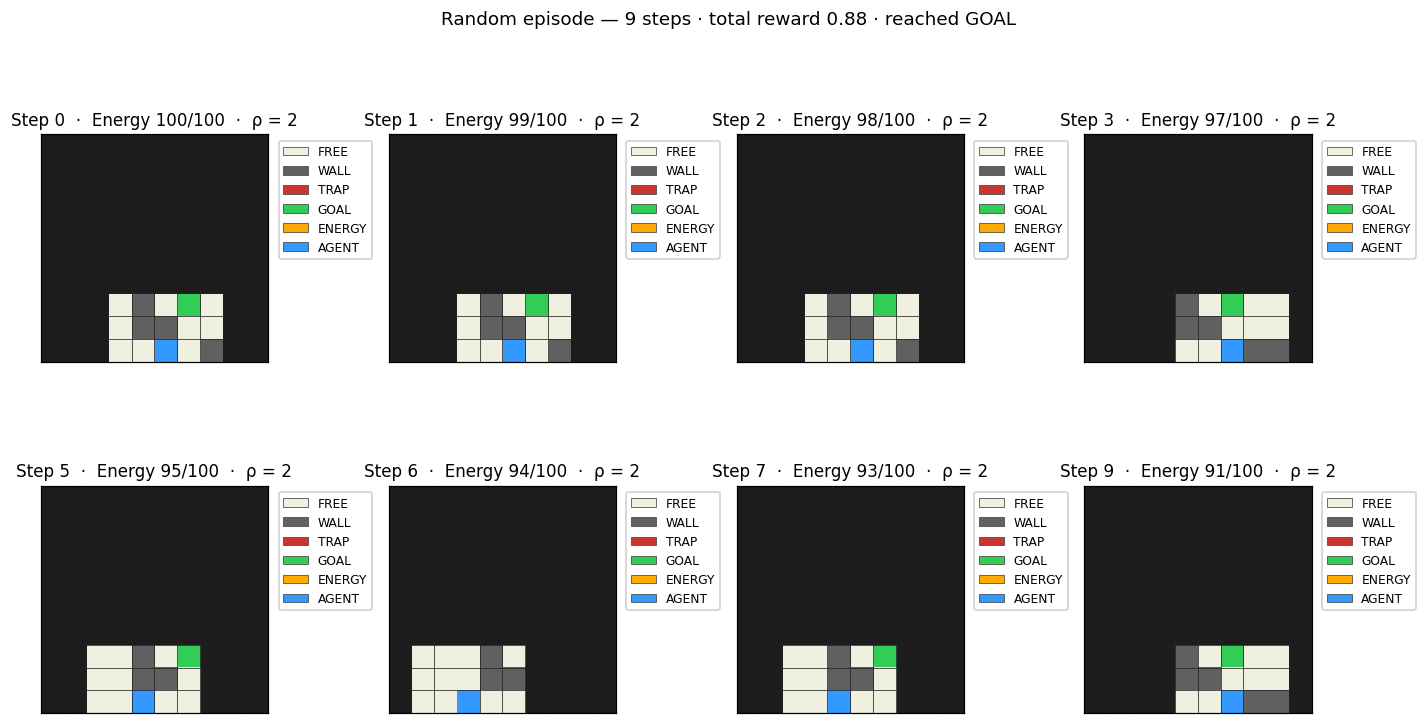

In [3]:
N_FRAMES = 8      # how many snapshots to show
SEED     = 42

env_ep = FogGridWorld(grid_size=10)
env_ep.reset(seed=SEED)

fig, axes = plt.subplots(2, N_FRAMES // 2, figsize=(N_FRAMES // 2 * 3.2, 7))
axes = list(axes.flat)

# Capture initial frame
env_ep.render_frame(axes[0])
frame_idx = 1

total_reward = 0.0
step = 0
done = False
interval = 1   # capture every step at first; adapt below once total length is known

# First pass: collect (step, reward, terminated) tuples
transitions = []
env_ep.reset(seed=SEED)   # reset again so we can replay

while not done:
    action = env_ep.action_space.sample()
    _, reward, terminated, truncated, info = env_ep.step(action)
    step += 1
    total_reward += reward
    transitions.append((step, reward, terminated or truncated, info))
    done = terminated or truncated

# Pick N_FRAMES - 1 evenly spaced steps to render (step 0 already captured above)
n_total = len(transitions)
indices = np.linspace(0, n_total - 1, N_FRAMES - 1, dtype=int)

# Replay and render at chosen indices
env_ep.reset(seed=SEED)
for i, (s, r, d, _info) in enumerate(transitions):
    env_ep.step(env_ep.action_space.sample())  # replay (same seed → same actions)
    if i in indices and frame_idx < len(axes):
        env_ep.render_frame(axes[frame_idx])
        frame_idx += 1

# Hide any unused subplots
for ax in axes[frame_idx:]:
    ax.set_visible(False)

result = 'reached GOAL' if transitions[-1][2] and transitions[-1][1] > 0 else \
         'hit TRAP' if transitions[-1][1] < -0.5 else \
         'energy depleted' if transitions[-1][3]['energy'] == 0 else 'max steps'

plt.suptitle(
    f'Random episode — {n_total} steps · total reward {total_reward:.2f} · {result}',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

## 3. Energy → Radius Shrinkage

The visible radius `ρ = max(r_min, round(r_max × e/E_max))` shrinks as energy drops.  
Here we freeze the map and artificially lower the energy to show the effect.

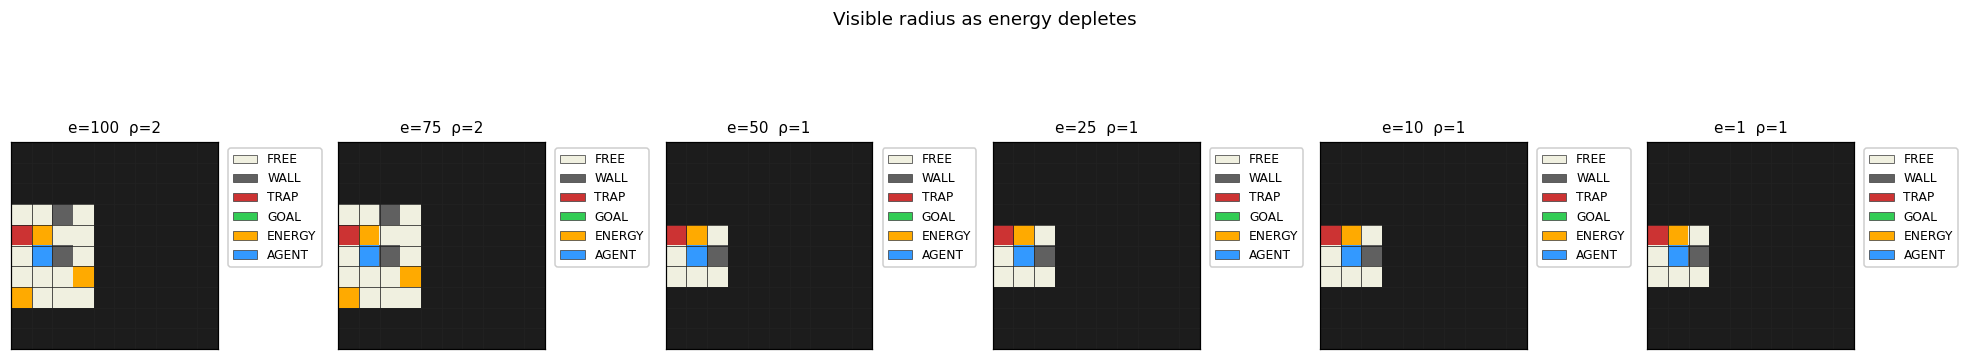

In [4]:
ENERGY_LEVELS = [100, 75, 50, 25, 10, 1]

env_r = FogGridWorld(grid_size=10)
env_r.reset(seed=7)

fig, axes = plt.subplots(1, len(ENERGY_LEVELS), figsize=(len(ENERGY_LEVELS) * 3, 3.8))

for ax, e in zip(axes, ENERGY_LEVELS):
    env_r._energy = e          # manually set energy to demonstrate radius formula
    rho = env_r._visible_radius()
    env_r.render_frame(ax, fog=True)
    ax.set_title(f'e={e}  ρ={rho}', fontsize=10)

plt.suptitle('Visible radius as energy depletes', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 4. Step-by-Step Animation

Runs a live episode frame by frame using `IPython.display.clear_output`.  
Change `DELAY` to control speed.

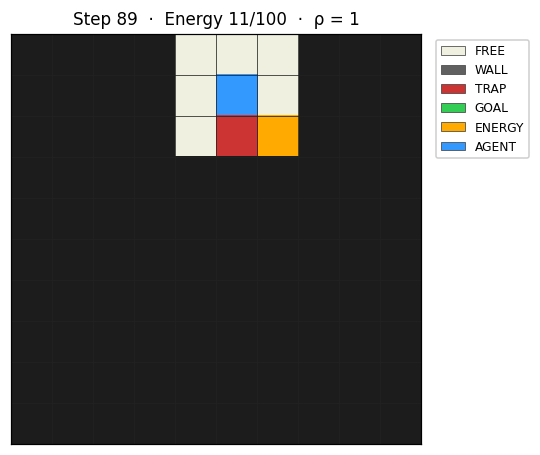

Episode ended after 89 steps  |  energy left: 11


In [5]:
import time
from IPython.display import clear_output

DELAY = 0.15   # seconds between frames
SEED  = 0

env_anim = FogGridWorld(grid_size=10)
env_anim.reset(seed=SEED)

done = False
while not done:
    clear_output(wait=True)

    fig, ax = plt.subplots(figsize=(5, 5))
    env_anim.render_frame(ax, fog=True)
    plt.tight_layout()
    plt.show()

    action = env_anim.action_space.sample()
    _, reward, terminated, truncated, info = env_anim.step(action)
    done = terminated or truncated
    time.sleep(DELAY)

# Final frame
clear_output(wait=True)
fig, ax = plt.subplots(figsize=(5, 5))
env_anim.render_frame(ax, fog=True)
plt.tight_layout()
plt.show()
print(f"Episode ended after {info['steps']} steps  |  energy left: {info['energy']}")